# 🎵 Análisis Exploratorio del Dataset: Pitchfork Reviews
**Objetivo:** Explorar los datos crudos, identificar inconsistencias ocultas (como valores nulos en géneros o años) y definir un flujo de limpieza y transformación riguroso que luego llevaremos a nuestro entorno local en VS Code.


**Diccionario de Variables Clave:**
* `reviewid`: Identificador único de la reseña (Llave primaria).Se utiliza únicamente para la vinculación de tablas y se excluye del modelo estadístico por no aportar valor predictivo.
* `title`: Nombre del álbum reseñado.
* `artist`: Nombre del artista o banda
* `score`: Variable Objetivo. Calificación otorgada por el crítico (rango 0.0 - 10.0).
* `year`: Año de lanzamiento original del álbum (obtenido de la tabla complementaria `years`).
* `genre`: Género musical asociado (Rock, Electronic, Jazz, etc.).
* `content`: Texto completo de la crítica (Data no estructurada).No utilizado en el modelo numérico actual


In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Conexión a la base de datos
conn = sqlite3.connect("../data/raw/database.sqlite")

# 2. Ver qué tablas existen
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tablas disponibles:")
display(tables)

# 3. Mostrar cada tabla (solo primeras filas)

print("\nTabla: reviews")
reviews = pd.read_sql("SELECT * FROM reviews LIMIT 5;", conn)
display(reviews)

print("\nTabla: genres")
genres = pd.read_sql("SELECT * FROM genres LIMIT 5;", conn)
display(genres)

print("\nTabla: years")
years = pd.read_sql("SELECT * FROM years LIMIT 5;", conn)
display(years)

print("\nTabla: artists")
artists = pd.read_sql("SELECT * FROM artists LIMIT 5;", conn)
display(artists)

print("\nTabla: labels")
labels = pd.read_sql("SELECT * FROM labels LIMIT 5;", conn)
display(labels)

df = pd.read_sql("""
SELECT
    r.reviewid,
    r.title,
    r.score,
    ar.artist,
    g.genre,
    y.year,
    l.label
FROM reviews r
LEFT JOIN artists ar ON r.reviewid = ar.reviewid
LEFT JOIN genres g ON r.reviewid = g.reviewid
LEFT JOIN years y ON r.reviewid = y.reviewid
LEFT JOIN labels l ON r.reviewid = l.reviewid
""", conn)

print("Filas originales en reviews:")
print(pd.read_sql("SELECT COUNT(*) as total FROM reviews", conn))

print("\nFilas después del JOIN:")
print(len(df))

print("\nDuplicados por reviewid:")
print(df.duplicated(subset=['reviewid']).sum())

print("\nPorcentaje de duplicación:")
print(f"{(8513 / 26902) * 100:.2f}%")
# 4. Cerrar conexión
conn.close()


Tablas disponibles:


,name
0,reviews
1,artists
2,genres
3,labels
4,years
5,content



Tabla: reviews


,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year
0,22703,mezzanine,massive attack,http://pitchfork.com/reviews/albums/22703-mezz...,9.3,0,nate patrin,contributor,2017-01-08,6,8,1,2017
1,22721,prelapsarian,krallice,http://pitchfork.com/reviews/albums/22721-prel...,7.9,0,zoe camp,contributor,2017-01-07,5,7,1,2017
2,22659,all of them naturals,uranium club,http://pitchfork.com/reviews/albums/22659-all-...,7.3,0,david glickman,contributor,2017-01-07,5,7,1,2017
3,22661,first songs,"kleenex, liliput",http://pitchfork.com/reviews/albums/22661-firs...,9.0,1,jenn pelly,associate reviews editor,2017-01-06,4,6,1,2017
4,22725,new start,taso,http://pitchfork.com/reviews/albums/22725-new-...,8.1,0,kevin lozano,tracks coordinator,2017-01-06,4,6,1,2017



Tabla: genres


...


Tabla: artists


,reviewid,artist
0,22703,massive attack
1,22721,krallice
2,22659,uranium club
3,22661,kleenex
4,22661,liliput



Tabla: labels


,reviewid,label
0,22703,virgin
1,22721,hathenter
2,22659,static shock
3,22659,fashionable idiots
4,22661,kill rock stars


Filas originales en reviews:
   total
0  18393

Filas después del JOIN:
26902

Duplicados por reviewid:
8513

Porcentaje de duplicación:
31.64%


Se detecta un aumento en el número de filas tras realizar los JOIN, lo que indica duplicación de registros.
Aproximadamente el 31.64% de los datos corresponde a duplicaciones generadas por relaciones uno a muchos (géneros, artistas, labels).
Esto puede sesgar los análisis si no se corrige.

## 1. El problema de los valores faltantes en Pitchfork Reviews
Los valores faltantes no están codificados como texto (por ejemplo, "unknown"), sino que aparecen como valores nulos (NaN). Estos se generan debido a la estructura relacional del dataset y al uso de LEFT JOIN entre tablas.

La variable label no se incluye en el análisis principal debido a su baja completitud y a que no es relevante para los objetivos del estudio.

In [7]:
#valores nulos por columna

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
reviewid       0
title          0
score          0
artist         0
genre       2718
year         611
label         45
dtype: int64


In [8]:
#Mostrar solo columnas con valores faltantes
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0
genre,2718
year,611
label,45


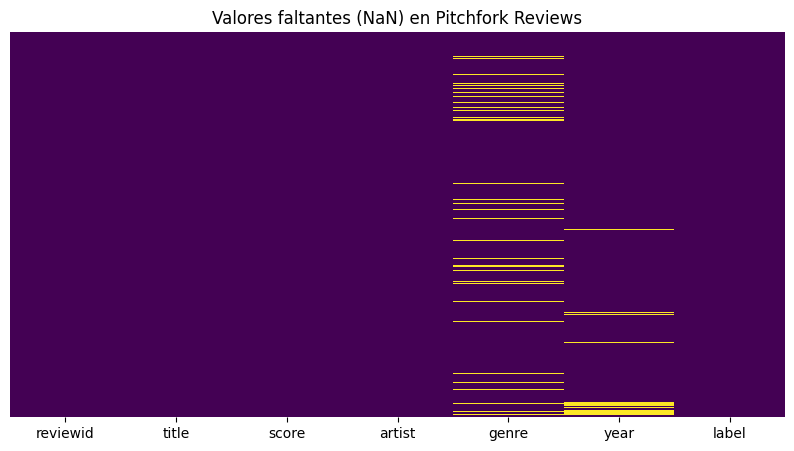

In [9]:
#3. Visualización (mapa de calor de NaN)
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Valores faltantes (NaN) en Pitchfork Reviews")
plt.show()

## 2. Variable objetivo Score
Distribución de las calificaciones otorgadas a los álbumes

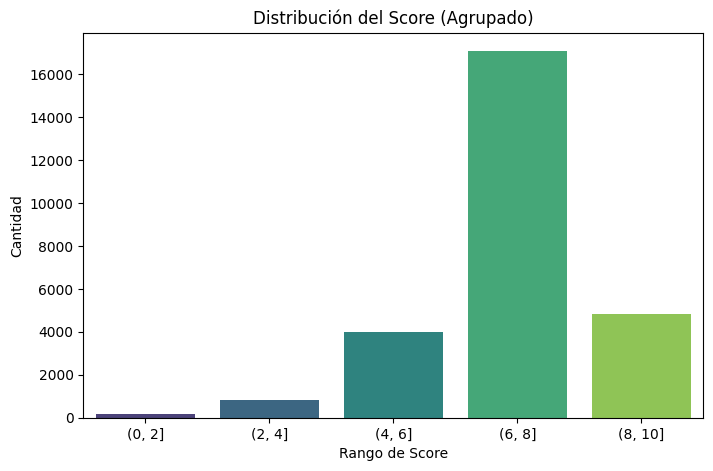

In [10]:
##la variable objetivo en este caso es continua (score),
# por lo que se analiza mediante distribuciones en lugar de variables categóricas.

plt.figure(figsize=(8,5))

sns.countplot(x=pd.cut(df['score'], bins=[0,2,4,6,8,10]), palette='viridis')

plt.title('Distribución del Score (Agrupado)')
plt.xlabel('Rango de Score')
plt.ylabel('Cantidad')

plt.show()

La mayoría de los álbumes se concentran en rangos medios-altos de score, especialmente entre 6 y 8.

## 3. EDA

In [11]:
df = df.copy()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False)

In [12]:
def plot_numeric_distributions(df, target_col):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    num_cols = [c for c in num_cols if c not in [target_col, 'reviewid']]

    n_cols = 2
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i],
                     bins=30, alpha=0.6, color='steelblue')
        axes[i].set_title(f'Distribución de {col} por score', fontweight='bold')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

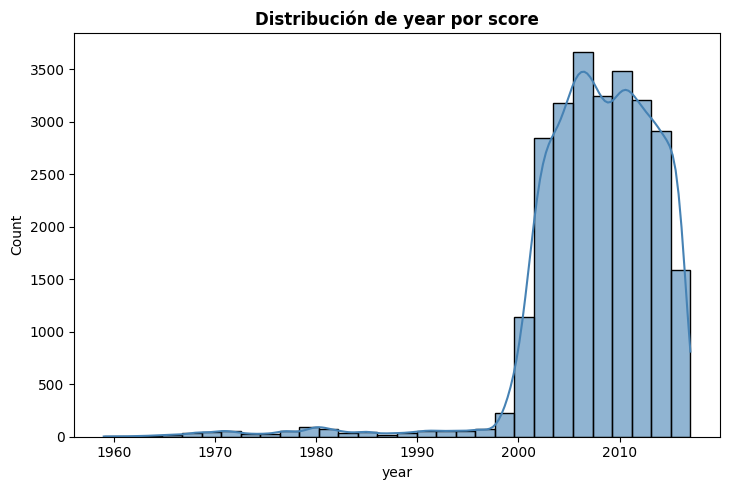

In [13]:
plot_numeric_distributions(df, target_col='score')

Generando gráficos de análisis...


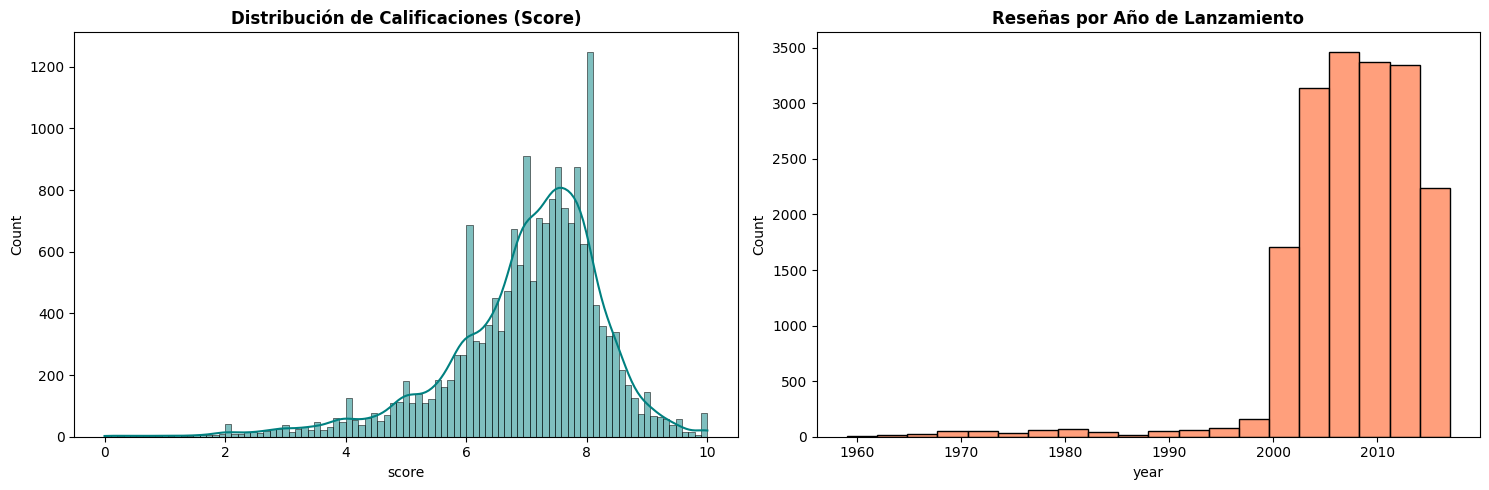

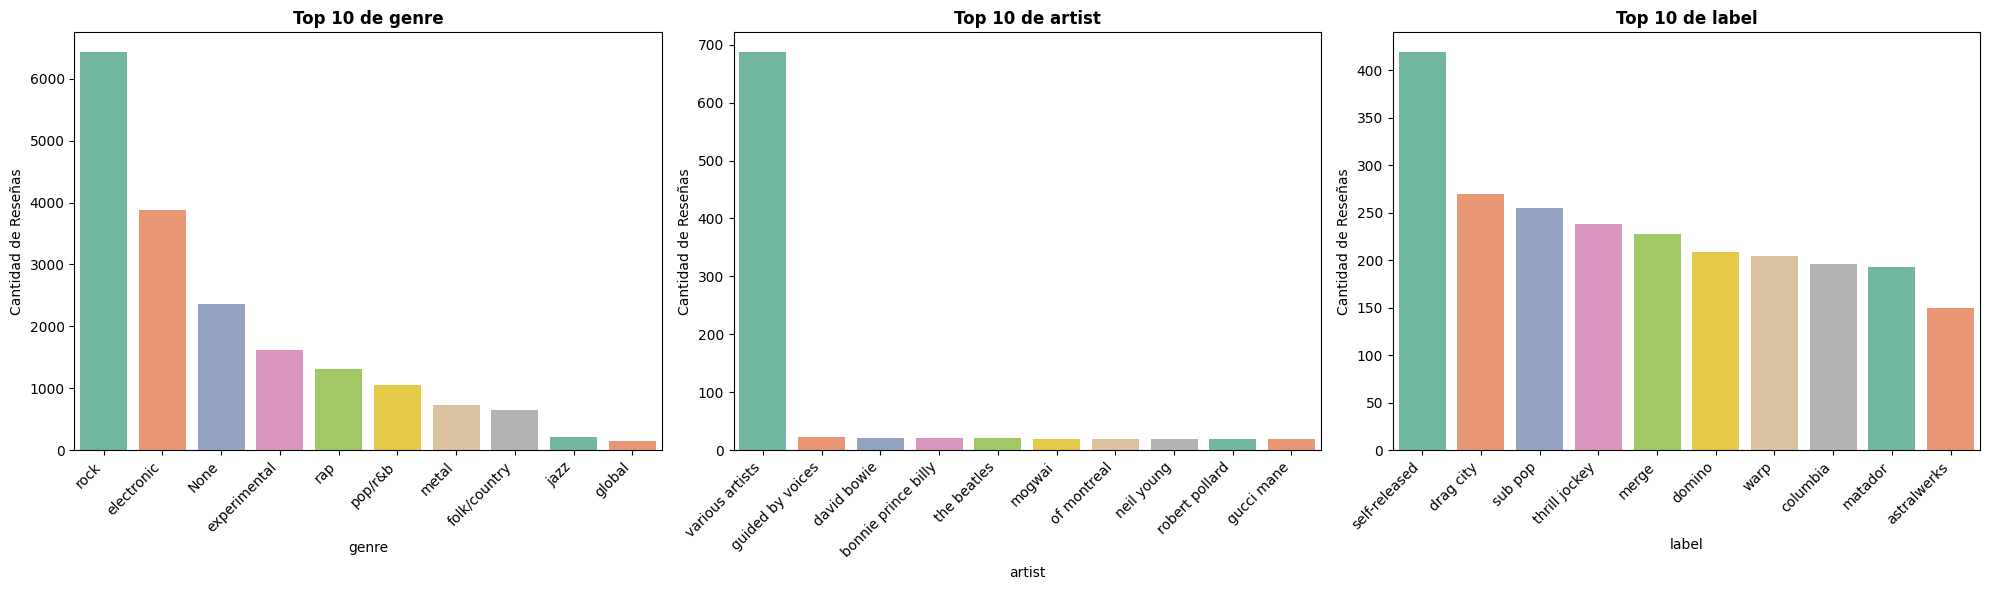

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Limpieza previa obligatoria
df_clean = df.drop_duplicates(subset=['reviewid']).copy()

# --- FUNCIÓN PARA NUMÉRICOS (Score y Year) ---
def plot_pitchfork_numeric(df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Distribución del Score
    sns.histplot(df['score'], kde=True, color='teal', ax=axes[0])
    axes[0].set_title('Distribución de Calificaciones (Score)', fontweight='bold')

    # Distribución por Año
    sns.histplot(df['year'].dropna(), kde=False, bins=20, color='coral', ax=axes[1])
    axes[1].set_title('Reseñas por Año de Lanzamiento', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- FUNCIÓN PARA CATEGÓRICOS (Top 10 para evitar manchas) ---
def plot_pitchfork_categorical(df, top_n=10):
    # Definimos las columnas que queremos ver
    cat_cols = ['genre', 'artist', 'label']

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for i, col in enumerate(cat_cols):
        # Obtenemos los 10 más frecuentes de esa columna
        top_data = df[col].value_counts().nlargest(top_n)

        # Graficamos usando los datos filtrados
        sns.barplot(x=top_data.index, y=top_data.values, ax=axes[i], palette='Set2')

        axes[i].set_title(f'Top {top_n} de {col}', fontweight='bold')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_ylabel('Cantidad de Reseñas')

    plt.tight_layout()
    plt.show()

# 3. Ejecutar las visualizaciones
print("Generando gráficos de análisis...")
plot_pitchfork_numeric(df_clean)
plot_pitchfork_categorical(df_clean)

#4) Outliers (Tratamiento de Valores Atípicos)

Calculando límites IQR y aplicando recorte (Capping) a score y year...
Reseñas originales: 18389
Reseñas tras el tratamiento: 18389 (¡Sin eliminar registros!)

--------------------------------------------------


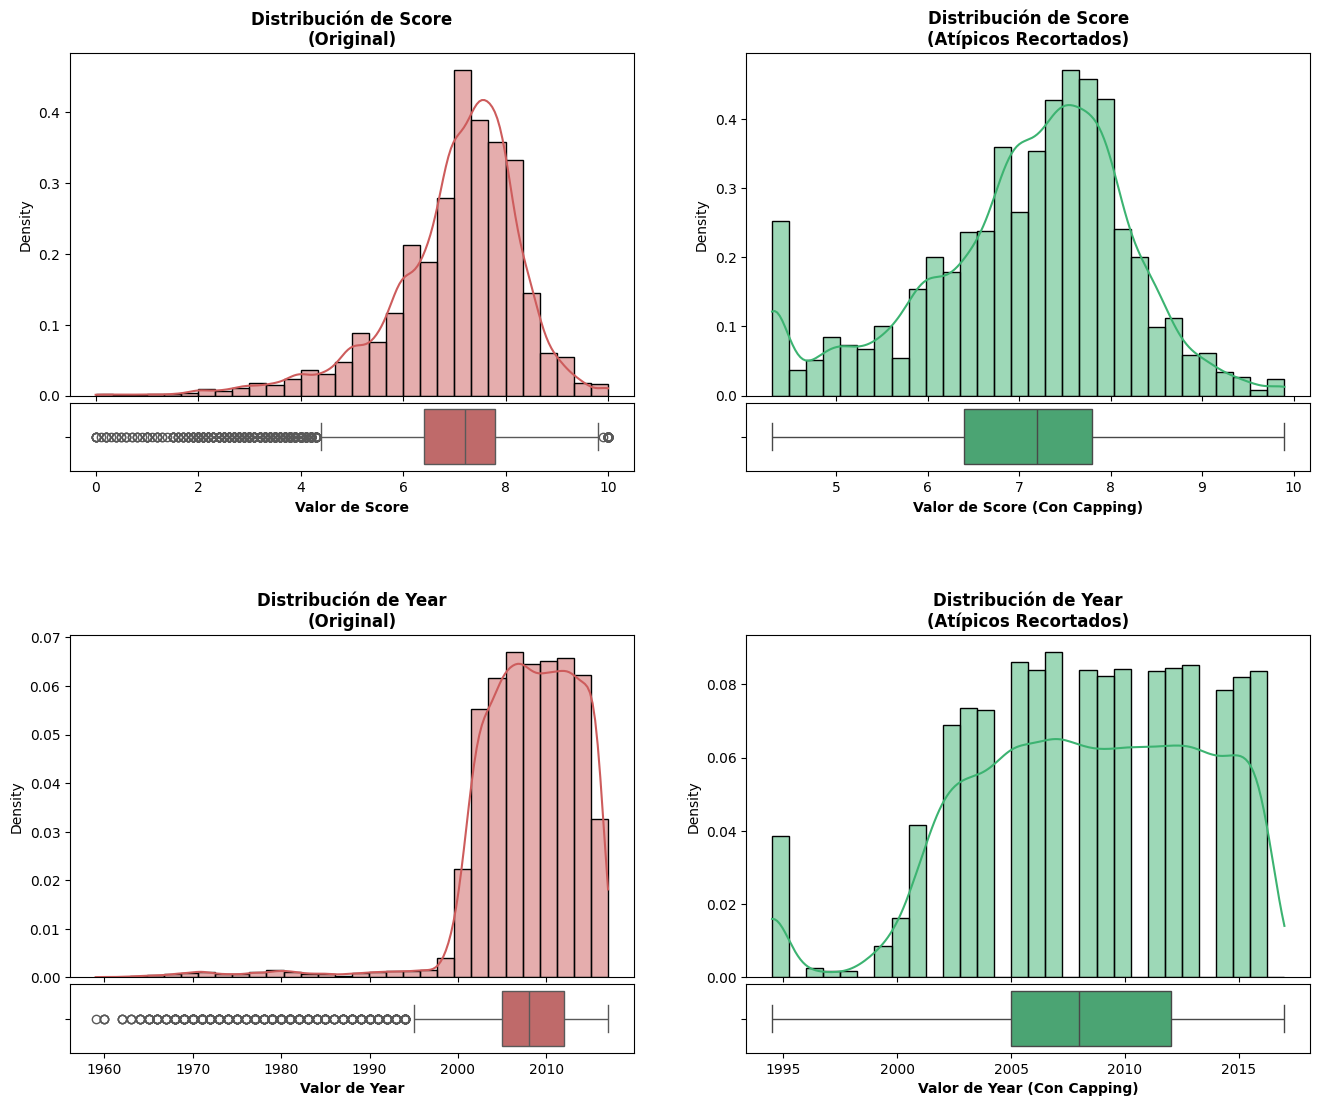

In [25]:

# 1. Identificar variables numéricas (score y year)
# Excluimos reviewid porque es un identificador, no una medida estadística
numerical_cols = ['score', 'year']

# 2. Creamos copia y aplicamos Capping (Recorte)
df_sin_outliers = df_clean.copy()

print("Calculando límites IQR y aplicando recorte (Capping) a score y year...")

for col in numerical_cols:
    # Calculamos los cuartiles
    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definimos límites
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Aplicamos el recorte (Capping)
    # Los valores menores al límite inferior pasan a ser el límite inferior
    # Los valores mayores al límite superior pasan a ser el límite superior
    df_sin_outliers[col] = np.clip(df_sin_outliers[col], lower_bound, upper_bound)

print(f"Reseñas originales: {len(df_clean)}")
print(f"Reseñas tras el tratamiento: {len(df_sin_outliers)} (¡Sin eliminar registros!)\n")
print("-" * 50)

# 3. Visualización Comparativa (Estilo Profesor)
fig, axs = plt.subplots(len(numerical_cols), 2, figsize=(16, 6 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    nombre_columna = col.capitalize()

    # --- COLUMNA IZQUIERDA: ORIGINAL ---
    ax_hist_orig = axs[i, 0]
    ax_hist_orig.set_title(f'Distribución de {nombre_columna}\n(Original)', fontweight='bold')
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True, ax=ax_hist_orig, color='indianred', stat='density')
    ax_hist_orig.set_xlabel('')
    ax_hist_orig.tick_params(labelbottom=False)

    # Boxplot Original
    ax_box_orig = ax_hist_orig.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df_clean[col].dropna(), ax=ax_box_orig, color='indianred')
    ax_box_orig.set_xlim(ax_hist_orig.get_xlim())
    ax_box_orig.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

    # --- COLUMNA DERECHA: CON CAPPING ---
    ax_hist_cap = axs[i, 1]
    ax_hist_cap.set_title(f'Distribución de {nombre_columna}\n(Atípicos Recortados)', fontweight='bold')
    sns.histplot(df_sin_outliers[col].dropna(), bins=30, kde=True, ax=ax_hist_cap, color='mediumseagreen', stat='density')
    ax_hist_cap.set_xlabel('')
    ax_hist_cap.tick_params(labelbottom=False)

    # Boxplot Recortado
    ax_box_cap = ax_hist_cap.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df_sin_outliers[col].dropna(), ax=ax_box_cap, color='mediumseagreen')
    ax_box_cap.set_xlim(ax_hist_cap.get_xlim())
    ax_box_cap.set_xlabel(f'Valor de {nombre_columna} (Con Capping)', fontweight='bold')

plt.subplots_adjust(hspace=0.7)
plt.show()

Tratamientos de nulos

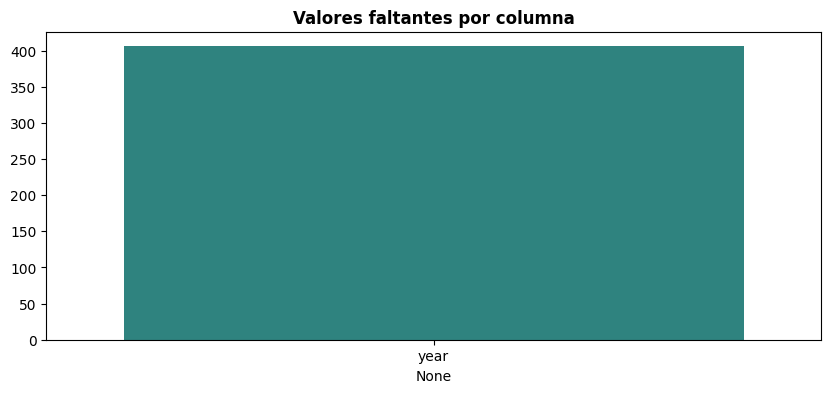

¡Listo! Ya no quedan huecos en el dataset.


In [26]:
# 1. Ver qué falta
missing_data = df_sin_outliers.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# 2. Graficar para el informe
if not missing_data.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
    plt.title('Valores faltantes por columna', fontweight='bold')
    plt.show()

# 3. RELLENAR (Lo que te pide el profe para limpiar)
df_sin_outliers['genre'] = df_sin_outliers['genre'].fillna('Unknown')
df_sin_outliers['label'] = df_sin_outliers['label'].fillna('Unknown')
df_sin_outliers['artist'] = df_sin_outliers['artist'].fillna('Various Artists')

print("¡Listo! Ya no quedan huecos en el dataset.")

# 4.5) Codificación de Variables Categóricas

In [29]:
from sklearn.preprocessing import LabelEncoder

# Creamos df_final para no arruinar los gráficos del punto 3
df_final = df_sin_outliers.copy()
le = LabelEncoder()

for col in ['genre', 'artist', 'label']:
    df_final[col] = le.fit_transform(df_final[col].astype(str))
print("✅ Transformación completada: Variables convertidas a formato numérico.")

#5) Correlación

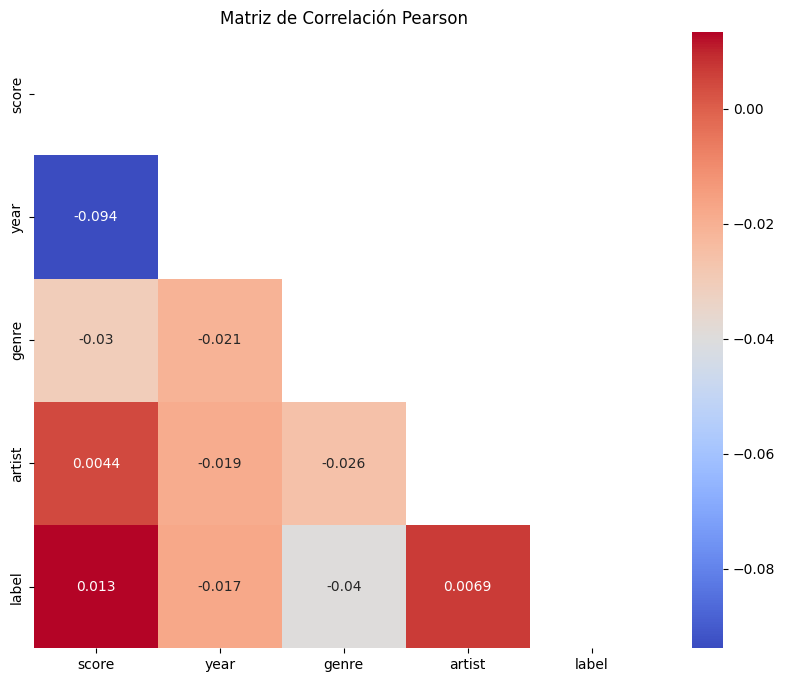

In [32]:
            # Matriz de Correlación de Pearson

# Lista manual de lo que queremos ver
cols = ['score', 'year', 'genre', 'artist', 'label']

# Usamos df_final porque TIENE los números
matriz = df_final[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap="coolwarm", mask=np.triu(np.ones_like(matriz, dtype=bool)))
plt.title("Matriz de Correlación Pearson")
plt.show()